In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
# show all columns
pd.set_option('display.max_columns', None)
import numpy as np


## ***LLM ratings***
Each of the 120 PolitiFact statements received exactly one rating from the LLM.

### 1.) ***S3***

In [3]:
llm_ratings_s3 = pd.read_csv("../data/llm_ratings_truth_s3_gpt-4o-mini.csv")

# missing data?
print(f"Missing data in LLM Ratings: {llm_ratings_s3.isnull().sum().sum()}")

#shape
print(f"LLM Ratings shape: {llm_ratings_s3.shape}")

llm_ratings_s3.head()

Missing data in LLM Ratings: 0
LLM Ratings shape: (120, 2)


,statement,rating
0,22 times Barack Obama said he did not have the...,1.0
1,6400 Ohioans lost manufacturing jobs in the m...,2.0
2,98 percent of small businesses make less than ...,1.0
3,A recent economic uptick appears to coincide w...,1.0
4,According to Wikipedia there are only five cou...,1.0


### 2.) ***S6***

In [4]:
llm_ratings_s6 = pd.read_csv("../data/llm_ratings_truth_s6_gpt-4o-mini.csv")

# missing data?
print(f"Missing data in LLM Ratings: {llm_ratings_s3.isnull().sum().sum()}")

#shape
print(f"LLM Ratings shape: {llm_ratings_s6.shape}")

llm_ratings_s6.head()

Missing data in LLM Ratings: 0
LLM Ratings shape: (120, 2)


,statement,rating
0,22 times Barack Obama said he did not have the...,3.0
1,6400 Ohioans lost manufacturing jobs in the m...,4.0
2,98 percent of small businesses make less than ...,4.0
3,A recent economic uptick appears to coincide w...,3.0
4,According to Wikipedia there are only five cou...,2.0


## ***Human annotations***
- 120 statements × 55 columns (1 text + 54 human annotators).
- Each unit_x column corresponds to a unique crowd worker.
- The NaNs represent missing annotations — many workers didn’t rate all 120 statements.
- Some rows (like your row 1) have multiple non-NaN values → those are ratings from different annotators for that statement.

So this table mirrors the setup described in the paper — sparse crowd annotations where each statement is rated by only a subset of humans.

### 1.) ***S3***

In [5]:
human_judgments_s3 = pd.read_csv("../data/reliability_matrix_s3.csv")

# missing data?
print(f"Missing data in Human Judgments: {human_judgments_s3.isnull().sum().sum()}")

# shape
print(f"Human Judgments shape: {human_judgments_s3.shape}")

human_judgments_s3.head()

Missing data in Human Judgments: 6156
Human Judgments shape: (120, 55)


,statement,unit_0,unit_1,unit_10,unit_100,unit_101,unit_102,unit_103,unit_104,unit_105,unit_106,unit_107,unit_108,unit_109,unit_11,unit_110,unit_111,unit_112,unit_113,unit_114,unit_115,unit_116,unit_117,unit_118,unit_119,unit_12,unit_120,unit_121,unit_122,unit_123,unit_124,unit_125,unit_126,unit_127,unit_128,unit_129,unit_13,unit_130,unit_131,unit_132,unit_133,unit_134,unit_135,unit_136,unit_137,unit_138,unit_139,unit_14,unit_140,unit_141,unit_142,unit_143,unit_144,unit_145,unit_146
0,22 times Barack Obama said he did not have the...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,NaN,2.0,NaN,2.0
2,98 percent of small businesses make less than ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

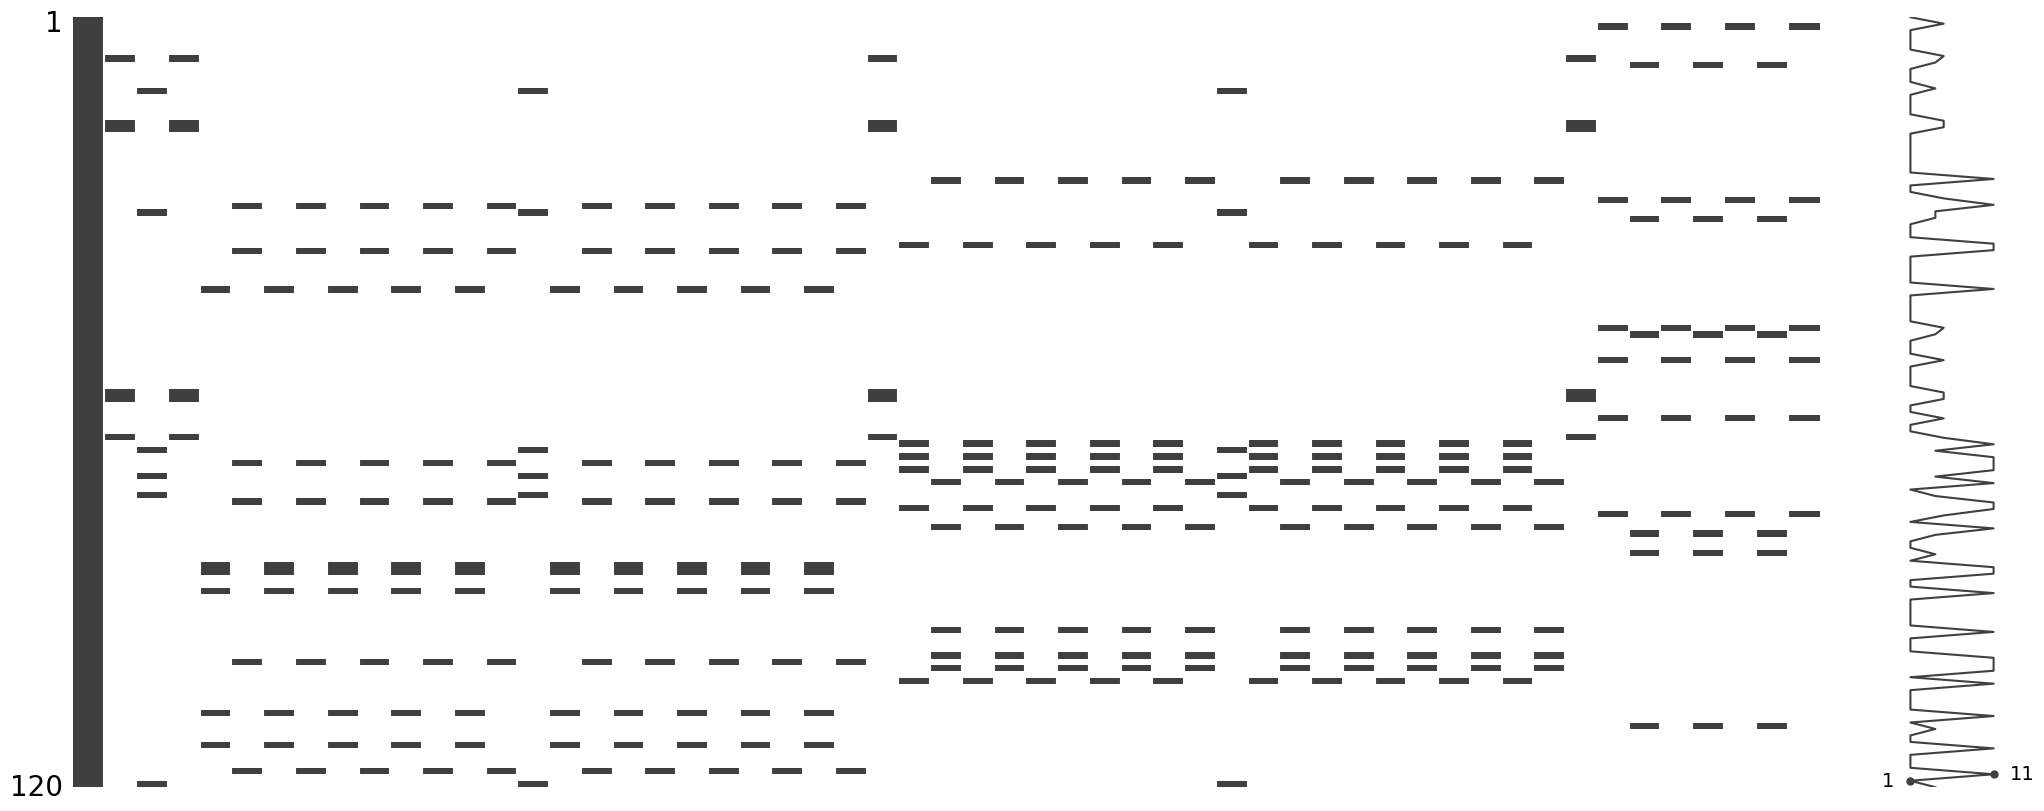

In [6]:
import missingno as mn

# show NaN pattern
mn.matrix(human_judgments_s3)

### 2.) ***S6***

In [7]:
human_judgments_s6 = pd.read_csv("../data/reliability_matrix_s6.csv")

# missing data?
print(f"Missing data in Human Judgments: {human_judgments_s6.isnull().sum().sum()}")

# shape
print(f"Human Judgments shape: {human_judgments_s6.shape}")

human_judgments_s6.head()

Missing data in Human Judgments: 3420
Human Judgments shape: (120, 31)


,statement,unit_0,unit_1,unit_10,unit_100,unit_101,unit_102,unit_103,unit_104,unit_105,unit_106,unit_107,unit_108,unit_109,unit_11,unit_110,unit_111,unit_112,unit_113,unit_114,unit_115,unit_116,unit_117,unit_118,unit_119,unit_12,unit_120,unit_121,unit_122,unit_123,unit_124
0,22 times Barack Obama said he did not have the...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,98 percent of small businesses make less than ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

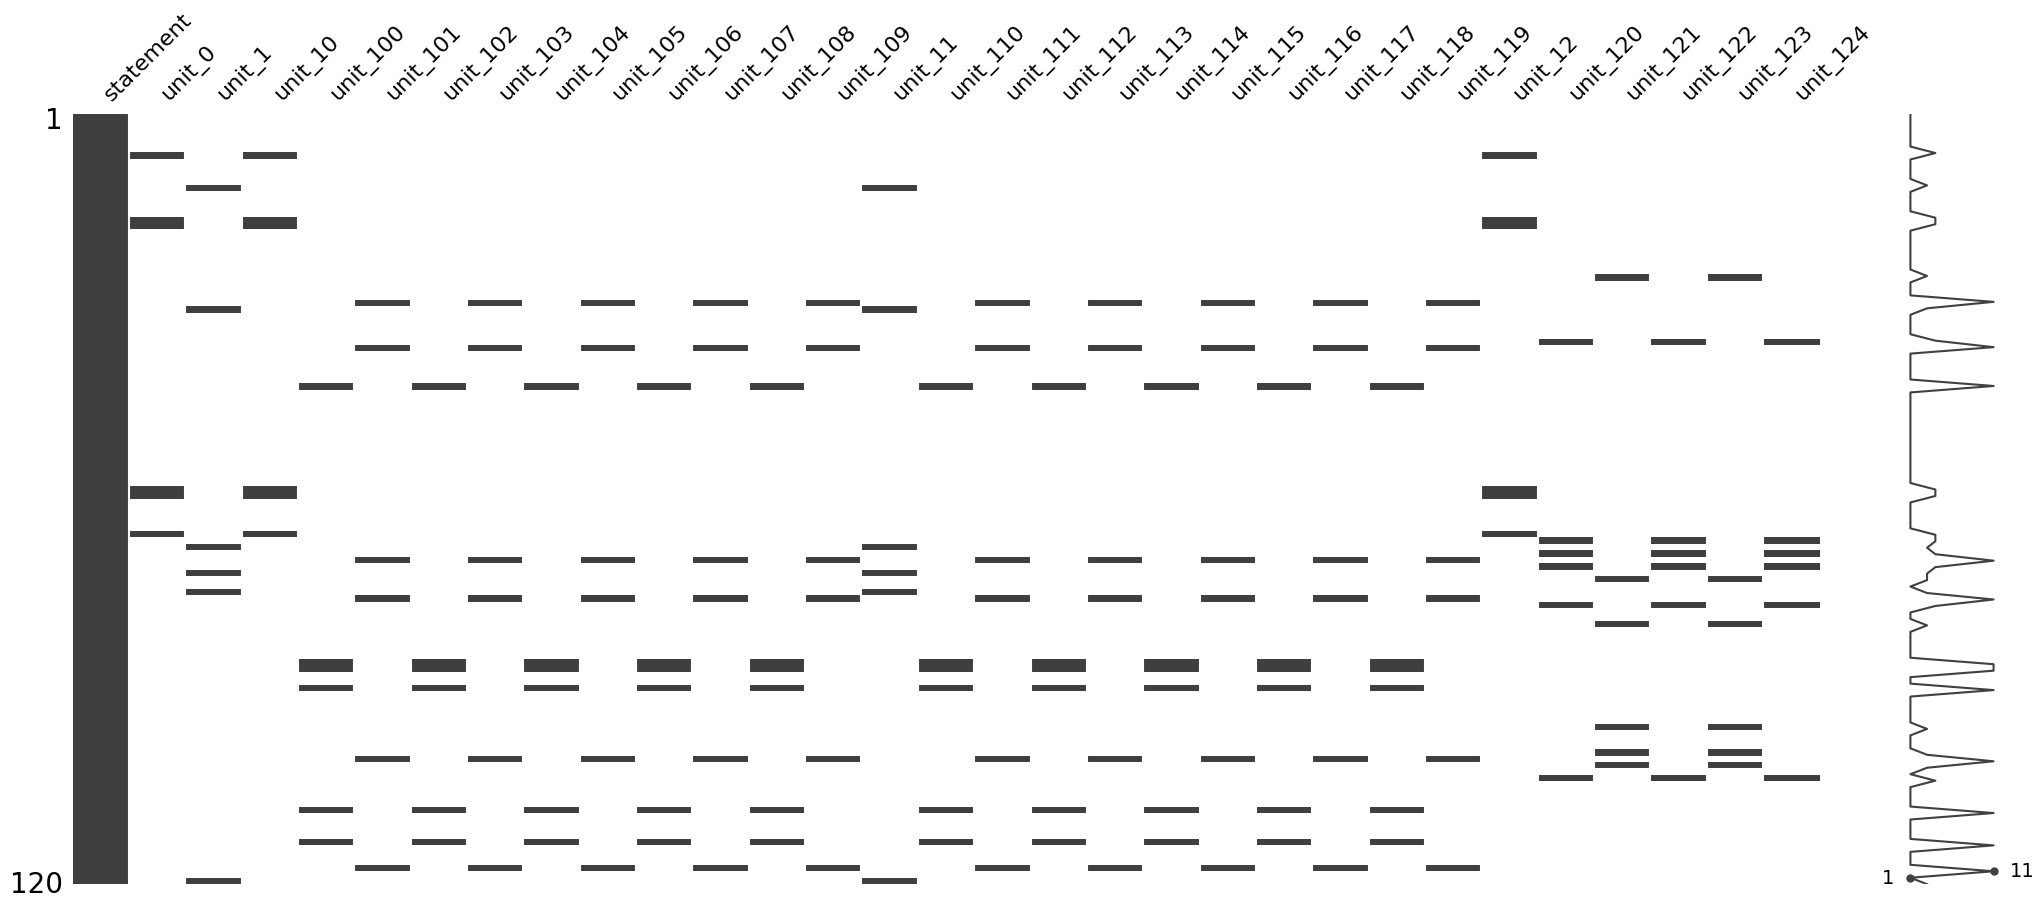

In [8]:
import missingno as mn

# show NaN pattern
mn.matrix(human_judgments_s6)

## ***Anaylsis***
### 2.) ***S3***

In [9]:
# rename rating to llm
llm_ratings_s3 = llm_ratings_s3.rename(columns={"rating": "GPT-4o mini"})

# rename unit_0 - unitn
human_judgments_s3.columns = ["statement"] + [f"human_#{i}" for i in range(1, len(human_judgments_s3.columns))]

# merge on 'id'
merged_s3_df = pd.merge(llm_ratings_s3, human_judgments_s3, on="statement", how="inner")
# shape of merged df
print(f"Merged DataFrame shape: {merged_s3_df.shape}")

# gpt-4o-mini ratings unique values
print(f"Unique values in GPT-4o mini ratings: {merged_s3_df['GPT-4o mini'].unique()}")

# unique ratings across all human judges
human_cols = [c for c in merged_s3_df.columns if c.startswith("human_#")]
unique_human_ratings = np.unique(merged_s3_df[human_cols].values[~pd.isna(merged_s3_df[human_cols].values)])
print("Human rating scale:", unique_human_ratings)

merged_s3_df.head()

Merged DataFrame shape: (120, 56)
Unique values in GPT-4o mini ratings: [1. 2. 0.]
Human rating scale: [0. 1. 2.]


,statement,GPT-4o mini,human_#1,human_#2,human_#3,human_#4,human_#5,human_#6,human_#7,human_#8,human_#9,human_#10,human_#11,human_#12,human_#13,human_#14,human_#15,human_#16,human_#17,human_#18,human_#19,human_#20,human_#21,human_#22,human_#23,human_#24,human_#25,human_#26,human_#27,human_#28,human_#29,human_#30,human_#31,human_#32,human_#33,human_#34,human_#35,human_#36,human_#37,human_#38,human_#39,human_#40,human_#41,human_#42,human_#43,human_#44,human_#45,human_#46,human_#47,human_#48,human_#49,human_#50,human_#51,human_#52,human_#53,human_#54
0,22 times Barack Obama said he did not have the...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,NaN,2.0,NaN,2.0
2,98 percent of small businesses make less than ...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


🎲 Random seed: 4252253110
✅ Found 54 valid human annotator columns.
✅ Keeping 48/120 rows with ≥2 human annotators.
✅ Added random judge baseline column: 'RANDOM_as_a_judge'
✅ Computed LLM-human disagreements for 1 LLM columns.
✅ Figure saved as SVG → ../svg/politifact_s3_barplot.svg


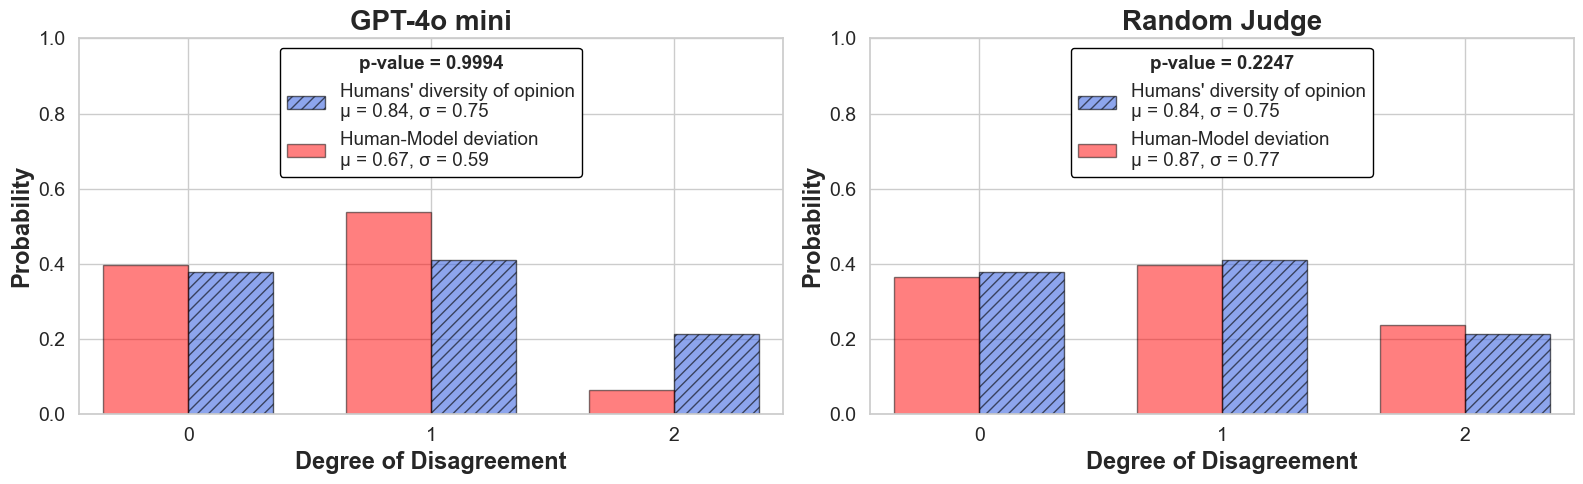

In [10]:
# Fix import path - add parent directory to Python path
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..'))

from llm_good_enough import LLMGoodEnough

# Identify human columns and LLM columns
HUMAN_COLS = [c for c in merged_s3_df.columns if c.startswith("human_#")]
LLM_COLS = ["GPT-4o mini"]   # Add more models here if desired

# Determine score boundaries from human ratings
MIN, MAX = int(np.min(unique_human_ratings)), int(np.max(unique_human_ratings))

# Create evaluator
judge = LLMGoodEnough(
    df=merged_s3_df,
    human_cols=HUMAN_COLS,
    llm_cols=LLM_COLS,
    min_score=MIN,
    max_score=MAX,
)

# Plot grid comparing all LLMs + Random Judge vs Humans
judge.plot_judges_grid(
    y_lim=1,
    save_path="../svg/politifact_s3_barplot.svg"
)


🎲 Random seed: 1025070883
✅ Found 54 valid human annotator columns.
✅ Keeping 48/120 rows with ≥2 human annotators.
✅ Added random judge baseline column: 'RANDOM_as_a_judge'


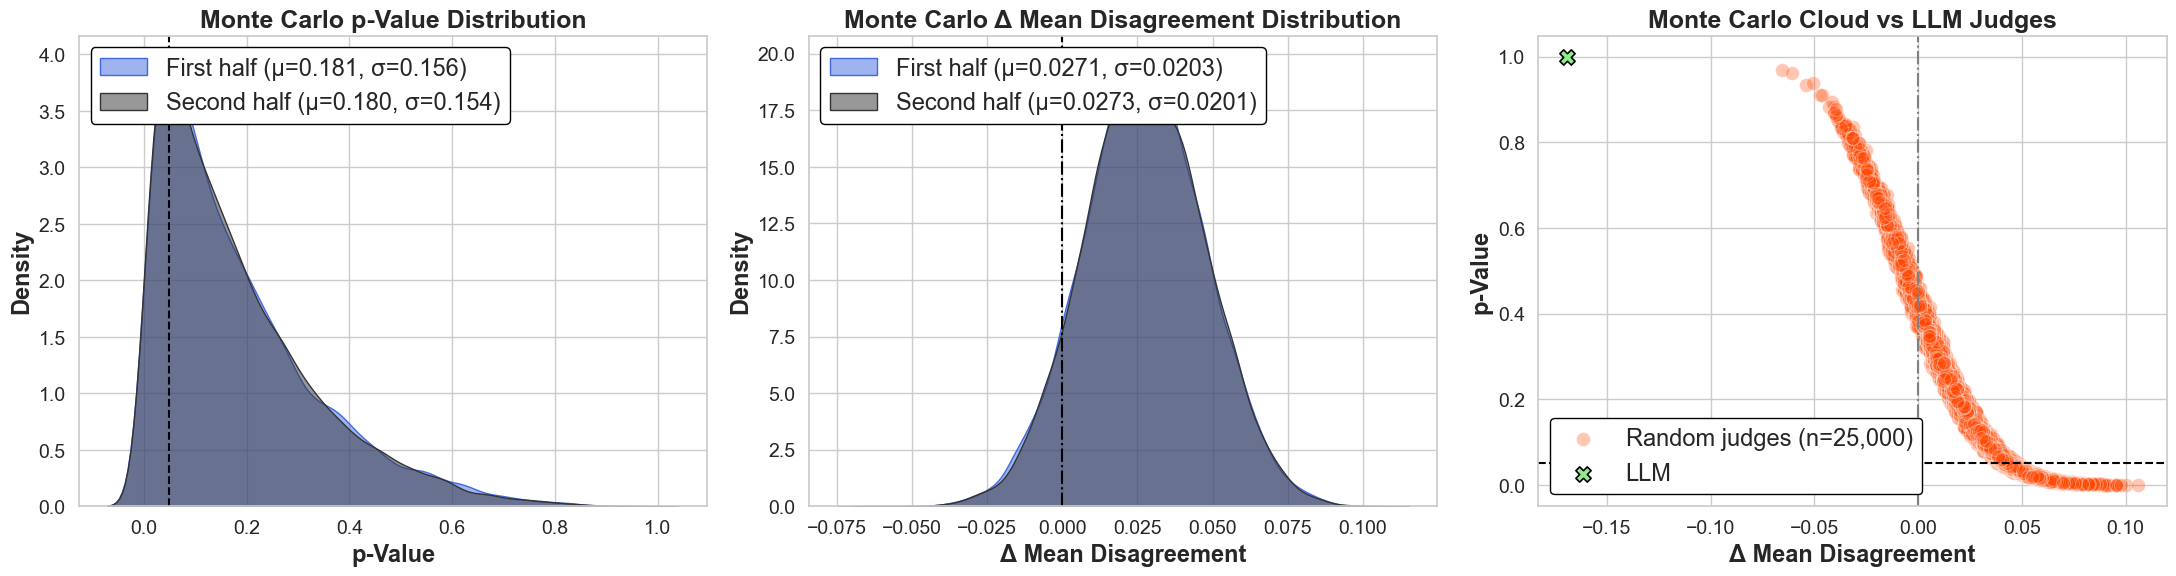

In [11]:
judge = LLMGoodEnough(
        df=merged_s3_df,
        human_cols=HUMAN_COLS,
        llm_cols=LLM_COLS,
        min_score=MIN, 
        max_score=MAX,
    )

judge.plot_monte_carlo_robustness(
    llm_col="GPT-4o mini",
    save_path="../svg/politifact_s3_monte_carlo_robustness.svg"
)

**Are humans judging coherently, or is the dataset too small / too noisy to evaluate an LLM judge reliably?**

📊 Sampling 5% of data (2 rows)... ✓ converged at 24,000 iterations (acceptance: 0.780)
📊 Sampling 10% of data (4 rows)... ✓ converged at 1,600 iterations (acceptance: 0.776)
📊 Sampling 20% of data (9 rows)... ✓ converged at 22,400 iterations (acceptance: 0.700)
📊 Sampling 30% of data (14 rows)... ✓ converged at 1,800 iterations (acceptance: 0.621)
📊 Sampling 40% of data (19 rows)... ✓ converged at 31,300 iterations (acceptance: 0.568)
📊 Sampling 50% of data (24 rows)... ✓ converged at 1,300 iterations (acceptance: 0.531)
📊 Sampling 60% of data (28 rows)... ✓ converged at 3,200 iterations (acceptance: 0.456)
📊 Sampling 70% of data (33 rows)... ✓ converged at 3,400 iterations (acceptance: 0.425)
📊 Sampling 80% of data (38 rows)... ✓ converged at 7,100 iterations (acceptance: 0.376)
📊 Sampling 90% of data (43 rows)... ✓ converged at 1,500 iterations (acceptance: 0.343)
📊 Sampling 100% of data (48 rows)... ✓ converged at 1,500 iterations (acceptance: 0.287)
✅ Figure saved → ../svg/politifa

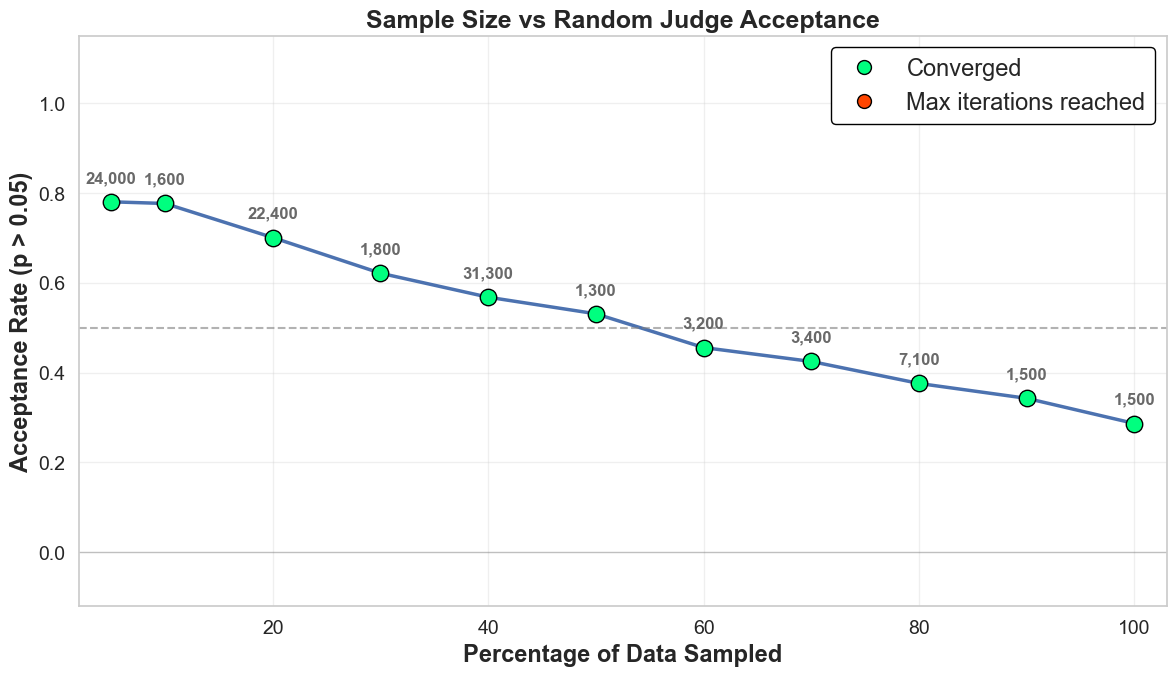

In [ ]:
judge.plot_human_stability_analysis(
    convergence_threshold=0.00001,
    min_iterations=1_000,
    max_iterations=100_000,
    save_path="../svg/politifact_s3_human_stability.svg"
)

📊 Sampling 10% of data (4 rows)... ✓ converged at 95,700 iterations (acceptance: 0.799)
📊 Sampling 20% of data (9 rows)... ✓ converged at 19,000 iterations (acceptance: 0.768)
📊 Sampling 50% of data (24 rows)... ✓ converged at 15,700 iterations (acceptance: 0.672)
📊 Sampling 100% of data (48 rows)... ✓ converged at 42,800 iterations (acceptance: 0.552)
📊 Sampling 150% of data (72 rows)... ⚠ max reached at 100,000 iterations (acceptance: 0.452)
📊 Sampling 200% of data (96 rows)... ✓ converged at 6,200 iterations (acceptance: 0.367)
📊 Sampling 250% of data (120 rows)... ✓ converged at 13,400 iterations (acceptance: 0.307)
📊 Sampling 300% of data (144 rows)... ✓ converged at 1,000 iterations (acceptance: 0.278)
📊 Sampling 350% of data (168 rows)... ✓ converged at 16,000 iterations (acceptance: 0.206)
📊 Sampling 400% of data (192 rows)... ✓ converged at 1,900 iterations (acceptance: 0.159)
📊 Sampling 450% of data (216 rows)... ✓ converged at 81,500 iterations (acceptance: 0.135)
📊 Sampling

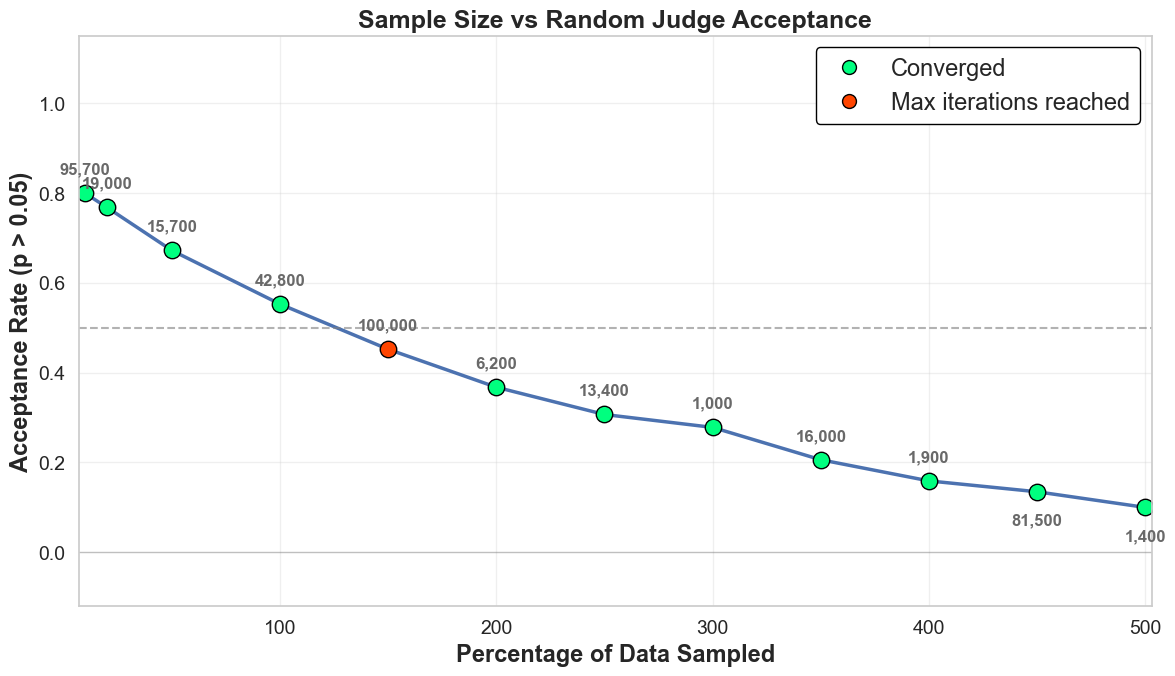

In [ ]:
judge.plot_human_stability_analysis(
    percentages=[50, 100, 150, 200, 250, 300, 350, 400, 450, 500],
    convergence_threshold=0.000005,
    min_iterations=10_000,
    max_iterations=500_000,
    save_path="../svg/politifact_s3_human_stability_100plus.svg"
)

In [ ]:
#judge.plot_human_stability_seed_robustness()   

### 2.) ***S6***

In [ ]:
# rename rating to llm
llm_ratings_s6 = llm_ratings_s6.rename(columns={"rating": "GPT-4o mini"})

# rename unit_0 - unit_146 to human_#1 to human_#147
human_judgments_s6.columns = ["statement"] + [f"human_#{i}" for i in range(1, len(human_judgments_s6.columns))]

# merge on 'id'
merged_s6_df = pd.merge(llm_ratings_s6, human_judgments_s6, on="statement", how="inner")
# shape of merged df
print(f"Merged DataFrame shape: {merged_s6_df.shape}")

# gpt-4o-mini ratings unique values
print(f"Unique values in GPT-4o mini ratings: {merged_s6_df['GPT-4o mini'].unique()}")

# unique ratings across all human judges
human_cols = [c for c in merged_s6_df.columns if c.startswith("human_#")]
unique_human_ratings = np.unique(merged_s6_df[human_cols].values[~pd.isna(merged_s6_df[human_cols].values)])
print("Human rating scale:", unique_human_ratings)

merged_s6_df.head()

Merged DataFrame shape: (120, 32)
Unique values in GPT-4o mini ratings: [3. 4. 2. 1. 5.]
Human rating scale: [0. 1. 2. 3. 4. 5.]


,statement,GPT-4o mini,human_#1,human_#2,human_#3,human_#4,human_#5,human_#6,human_#7,human_#8,human_#9,human_#10,human_#11,human_#12,human_#13,human_#14,human_#15,human_#16,human_#17,human_#18,human_#19,human_#20,human_#21,human_#22,human_#23,human_#24,human_#25,human_#26,human_#27,human_#28,human_#29,human_#30
0,22 times Barack Obama said he did not have the...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,98 percent of small businesses make less than ...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


🎲 Random seed: 2749998934
✅ Found 30 valid human annotator columns.
✅ Keeping 36/120 rows with ≥2 human annotators.
✅ Added random judge baseline column: 'RANDOM_as_a_judge'
✅ Computed LLM-human disagreements for 1 LLM columns.
✅ Figure saved as SVG → ../svg/politifact_s6_barplot.svg


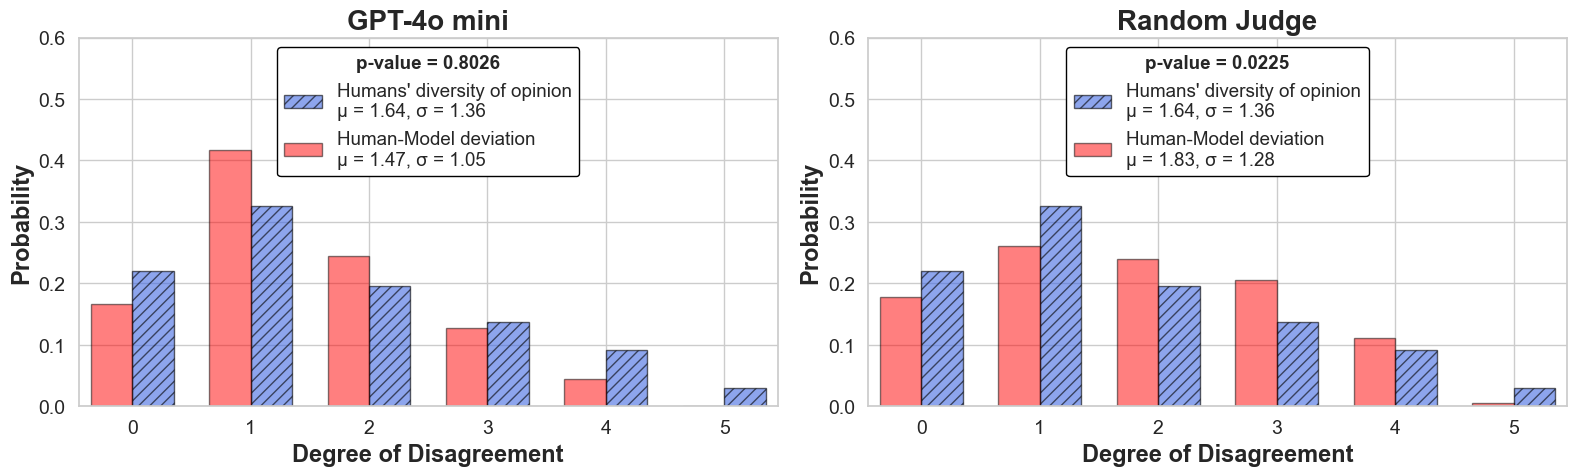

In [ ]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..'))

from llm_good_enough import LLMGoodEnough

HUMAN_COLS = [c for c in merged_s6_df.columns if c.startswith("human_#")]
MIN, MAX = int(np.min(unique_human_ratings)), int(np.max(unique_human_ratings))

judge = LLMGoodEnough(
    df=merged_s6_df,
    human_cols=HUMAN_COLS,
    llm_cols=LLM_COLS,
    min_score=MIN,
    max_score=MAX,
    verbosity=1
)

judge.plot_judges_grid(
    #y_lim=1,
    save_path="../svg/politifact_s6_barplot.svg"
)

#### What’s going on conceptually
Each run in your loop:
- Generates a new random judge (since you reinitialize with a different seed each time).
- Therefore produces a different RANDOM_as_a_judge column.
- And hence, different LLM–Human vs. Human–Human Mann–Whitney test results.
That means your p-values and corresponding means/stds for the random baseline are random variables themselves.
So instead of treating them as one-off results, you can study their sampling distribution — that is, how stable or variable your test statistic is.
This is a bootstrap-like robustness check of your “LLM is good enough” evaluation.

Why a p-value distribution is meaningful
It helps answer:
- “How consistent is my statistical conclusion?”
- “Is the LLM consistently better than random?”
- “How much overlap is there between LLM and random judge performance?”


If, for instance:
- LLM p-values are consistently small (<0.05) while random judge p-values vary broadly or cluster near 1,
→ strong evidence that the LLM is robustly better than random.

But if both overlap substantially across runs,
→ your “LLM is good enough” conclusion may not be stable.

🎲 Random seed: 3853906131
✅ Found 30 valid human annotator columns.
✅ Keeping 36/120 rows with ≥2 human annotators.
✅ Added random judge baseline column: 'RANDOM_as_a_judge'


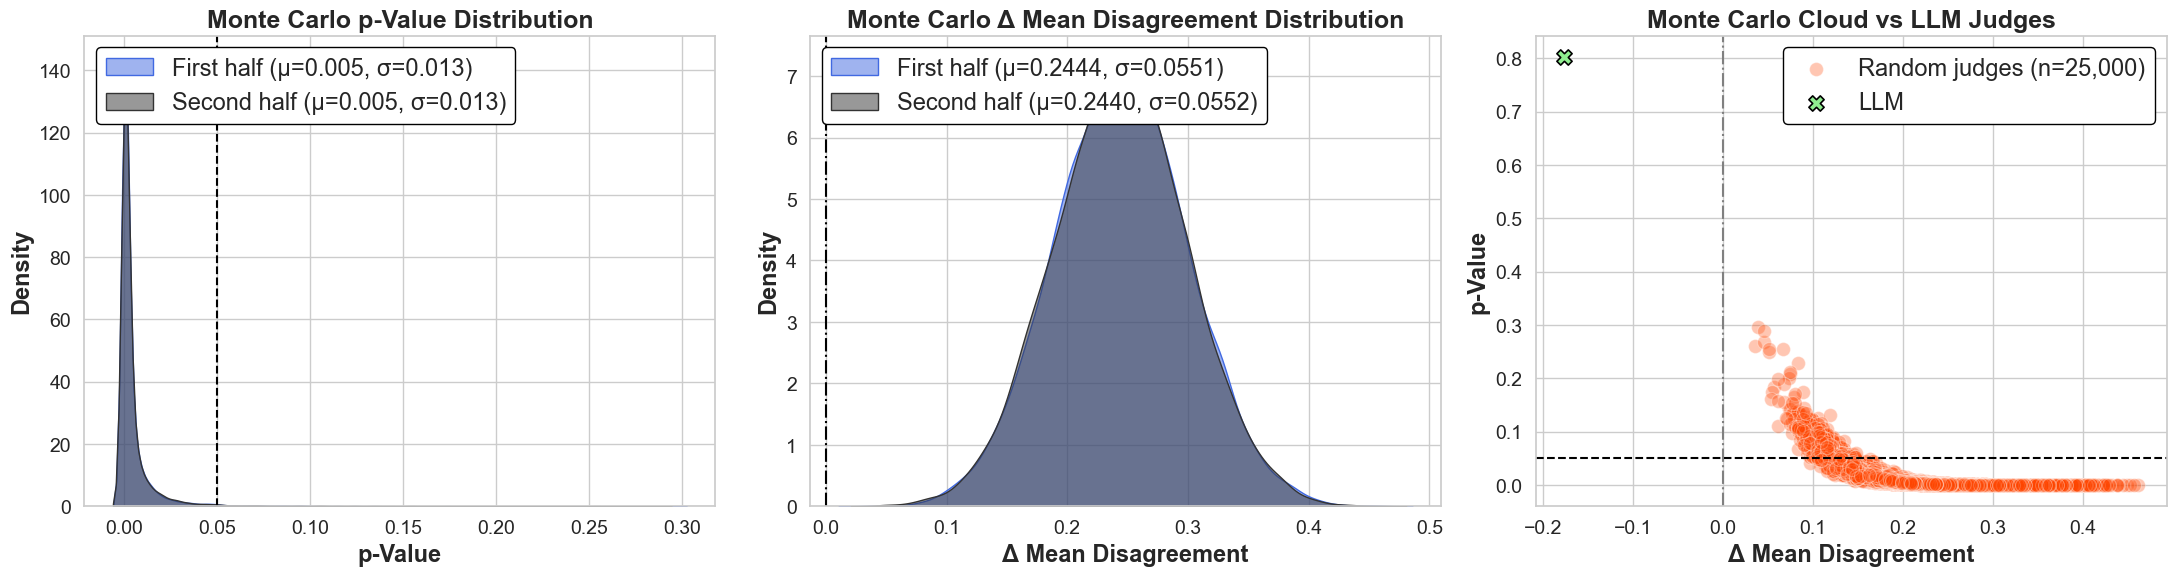

In [ ]:
judge = LLMGoodEnough(
        df=merged_s6_df,
        human_cols=HUMAN_COLS,
        llm_cols=LLM_COLS,
        min_score=MIN, 
        max_score=MAX,
    )

judge.plot_monte_carlo_robustness(
    llm_col="GPT-4o mini",
    save_path="../svg/politifact_s6_monte_carlo_robustness.svg"
)

#### ***`Interpretations`***
***`Panel (C)`***
- The dashed line at p = 0.05 marks the statistical significance threshold.
- The LLM’s blue point lies well above this line and close to zero on the x-axis, showing its disagreement with humans is small and not statistically significant — behaving like a human rater.
- The random judges (red) cluster below the dashed line with larger ΔMean values, indicating consistently higher and significant disagreement.
- This demonstrates that the LLM’s disagreement falls within natural human variability, whereas random judges deviate substantially and inconsistently, confirming the LLM is “good enough.”

| Panel | Statistic                                                    | Visualization | What it answers                                                                                     | Type of insight                  |
| ----- | ------------------------------------------------------------ | ------------- | --------------------------------------------------------------------------------------------------- | -------------------------------- |
| **A** | Mann-Whitney p-value                                         | KDE           | “Is the random judge *statistically* worse than humans?”  — and is that result stable across seeds? | **Significance stability**       |
| **B** | Δ Mean Disagreement = Mean(Random–Human) − Mean(Human–Human) | KDE           | “By *how much* does the random judge disagree more than humans?”  — and is that magnitude stable?   | **Effect-size stability**        |
| **C** | Scatter of (p-value vs Δ Mean)                               | Scatterplot   | “How do significance and effect size co-vary across iterations?”                                    | **Joint behavior / correlation** |


#### **Are humans judging coherently, or is the dataset too small / too noisy to evaluate an LLM judge reliably?**
---
***Human Stability Test — What It Does, What It Plots, and How to Interpret It***

The human-stability test evaluates whether human ratings are coherent enough, and whether there is enough data, to meaningfully evaluate LLM-as-a-judge performance. The goal is to determine if humans produce a stable disagreement signal or if human noise is so large that even a random judge becomes indistinguishable from real annotators.

***How the Algorithm Works (Adaptive Sampling)***

Uses **adaptive sampling**: for each percentage, iterations continue until the acceptance rate converges (split-half difference < threshold) rather than using fixed iteration counts. This is statistically sound because smaller samples (noisier) automatically get more iterations, while larger samples stop early once stable.

For each percentage of sampled data (5%, 10%, …, 100%):

1. **Bootstrap the dataset** by sampling that percentage of rows with replacement.  
2. **Compute human–human disagreements** within the subsample.  
3. **Use the `RANDOM_as_a_judge` column** to compute random-judge–human disagreements.  
4. **Run a Mann–Whitney U test**:  
   - p > 0.05 → random judge is statistically indistinguishable from humans → label **1**  
   - p ≤ 0.05 → random judge is rejected → label **0**  
5. **Check convergence** every `check_interval` iterations (after `min_iterations`):
   - Split decisions into two halves and compare acceptance rates.
   - If the means differ by **less than 1%** → **converged**, stop iterating.
   - If not converged and below `max_iterations` → continue.
6. Record: acceptance rate, whether converged, and number of iterations used.

***What the Plot Shows***
- **X-axis:** Percentage of the dataset sampled.  
- **Y-axis:** Acceptance rate (how often the random judge is "accepted" as human-like).  
- **Green dot:** **Converged** — the acceptance rate stabilized before max iterations.  
- **Red dot:** **Max iterations reached** — did not converge, estimate may be unstable.
- **Annotations above dots:** Number of iterations needed (reveals "difficulty" per sample size).

Convergence (dot color) and noise (acceptance rate) are different:
- **Color = reliability** of the estimate (converged vs not).  
- **Y-value = strength of human alignment** (lower = humans distinguishable from random; higher = noisy humans).

***Interpretation: Understanding Trend Patterns***

The MWU test gains statistical power as sample size increases:
- **Small samples (5-10%):** High acceptance rate → not enough power to detect that random is worse than humans (Type II error / false negative).
- **Large samples (50-100%):** Low acceptance rate → sufficient power to reliably reject the random judge as non-human-like.

**Trend patterns and what they mean:**
- **Downhill trend** → Expected for random/bad judges. Power increases with sample size, rejection becomes reliable. This is a sanity check: a random judge *should* be rejected with enough data.
- **Flat high (~1.0)** → Judge is consistently human-like across all sample sizes (good judge, or humans are very noisy).
- **Flat low (~0.0)** → Judge is clearly bad, rejected even with tiny samples.
- **Uphill trend** → Suspicious, investigate data quality or methodology.
- **Erratic (many red points)** → High variance in the data, may need more data or iterations.

***Interpretation of a Plot with Acceptance Rates ≈ 1.0***
If the plot shows that acceptance rates are close to **1.0** for all percentages:
- The random judge almost always appears human-like.
- This means human–human disagreement is very large or inconsistent.
- Humans are not well-aligned, and the human signal is too weak to distinguish real raters from randomness.

If most dots are **red**, this indicates:
- Human disagreement does not converge when subsampling.
- The data may be too noisy or need more iterations.

***Summary***
The human-stability test checks whether your human judgments form a reliable baseline.  
- **Green dots** = converged estimates; **Red dots** = did not converge (max iterations reached).
- **Downhill trend** = expected behavior, methodology working correctly.
- **High acceptance rates** = noisy or unaligned humans.
- **Iteration annotations** reveal which sample sizes are "harder" to stabilize.

If random judges consistently look "human," the dataset is too noisy to be used as ground truth for evaluating LLM judges.


📊 Sampling 5% of data (1 rows)... ✓ converged at 2,800 iterations (acceptance: 0.804)
📊 Sampling 10% of data (3 rows)... ✓ converged at 10,000 iterations (acceptance: 0.699)
📊 Sampling 20% of data (7 rows)... ⚠ max reached at 100,000 iterations (acceptance: 0.604)
📊 Sampling 30% of data (10 rows)... ✓ converged at 5,900 iterations (acceptance: 0.555)
📊 Sampling 40% of data (14 rows)... ✓ converged at 3,300 iterations (acceptance: 0.509)
📊 Sampling 50% of data (18 rows)... ✓ converged at 5,400 iterations (acceptance: 0.441)
📊 Sampling 60% of data (21 rows)... ✓ converged at 2,800 iterations (acceptance: 0.398)
📊 Sampling 70% of data (25 rows)... ✓ converged at 9,600 iterations (acceptance: 0.356)
📊 Sampling 80% of data (28 rows)... ✓ converged at 13,600 iterations (acceptance: 0.323)
📊 Sampling 90% of data (32 rows)... ✓ converged at 26,700 iterations (acceptance: 0.291)
📊 Sampling 100% of data (36 rows)... ✓ converged at 1,700 iterations (acceptance: 0.267)
✅ Figure saved → ../svg/poli

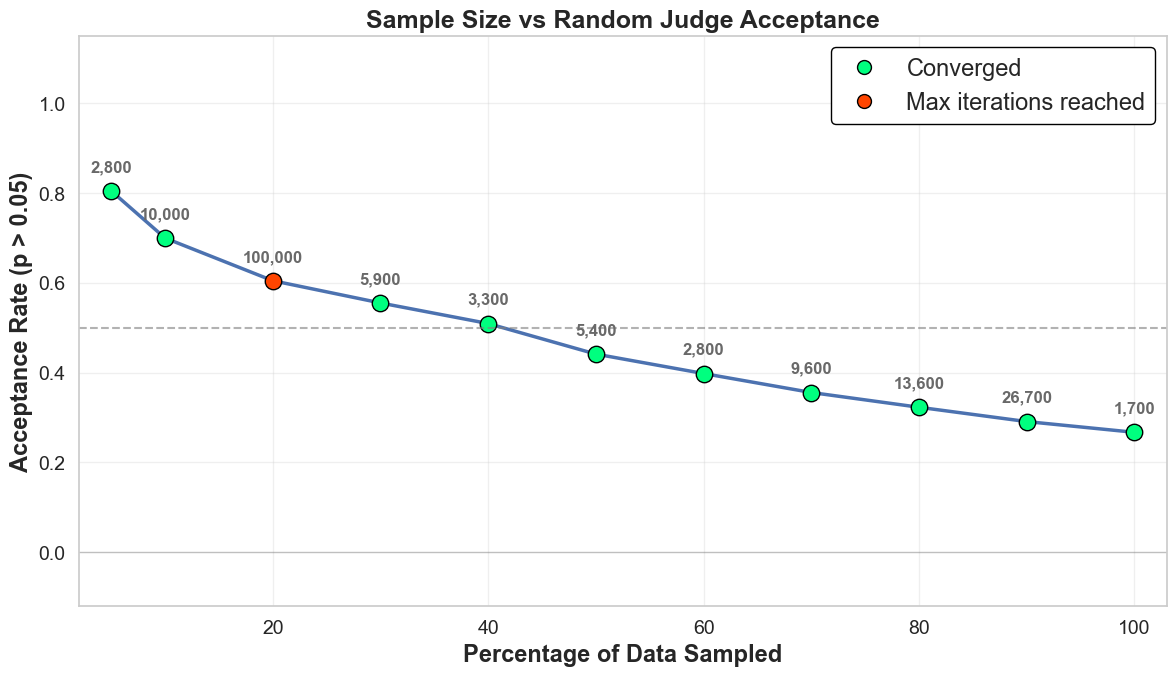

In [ ]:
judge.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    min_iterations=20_000,
    max_iterations=500_000,
    save_path="../svg/politifact_s6_human_stability.svg"
)

In [ ]:
#judge.plot_human_stability_seed_robustness()